Device: cpu

📁 Loading data...
Snow season days: 2410
Observations: 37

🔁 Running LOO with 5 fixed seeds...
Seed 42 completed
Seed 123 completed
Seed 456 completed
Seed 789 completed
Seed 1024 completed

TABLE 1: COMPLETE METRICS COMPARISON
Metric                     ERA5   PINN (avg)     Improvement
------------------------------------------------------------
MAE                      19.840        8.812          ↓11.03
RMSE                     25.960       17.865           ↓8.10
R2                        0.746        0.880          ↑0.134
NSE                       0.746        0.880          ↑0.134
KGE                       0.814        0.894          ↑0.080
Willmott's d              0.924        0.967          ↑0.043
PBIAS (%)                -0.248        3.203          ↓-3.0%
RSR                       0.504        0.347           ↓0.16
MAPE (%)                 33.519       15.794          ↓17.73
SMAPE (%)                26.506       10.716          ↓15.79
Explained Var             0

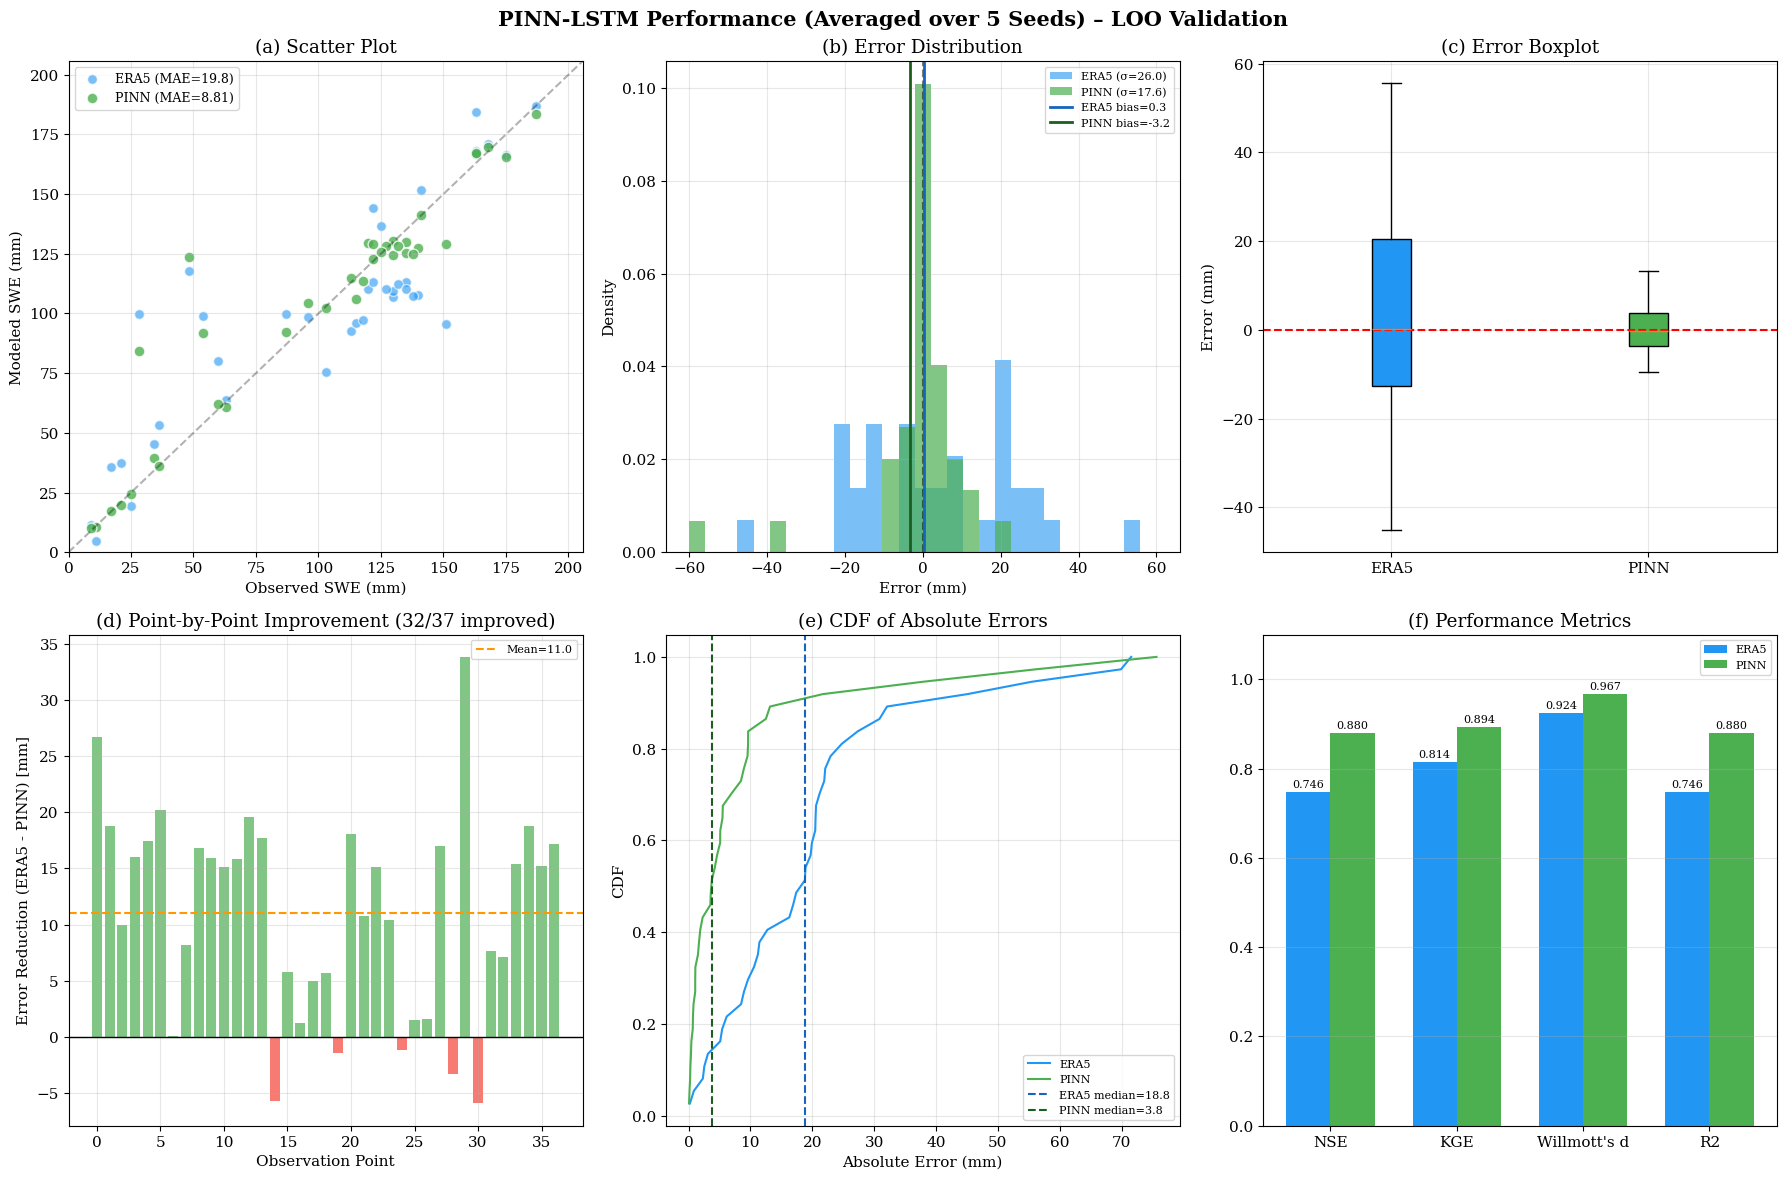

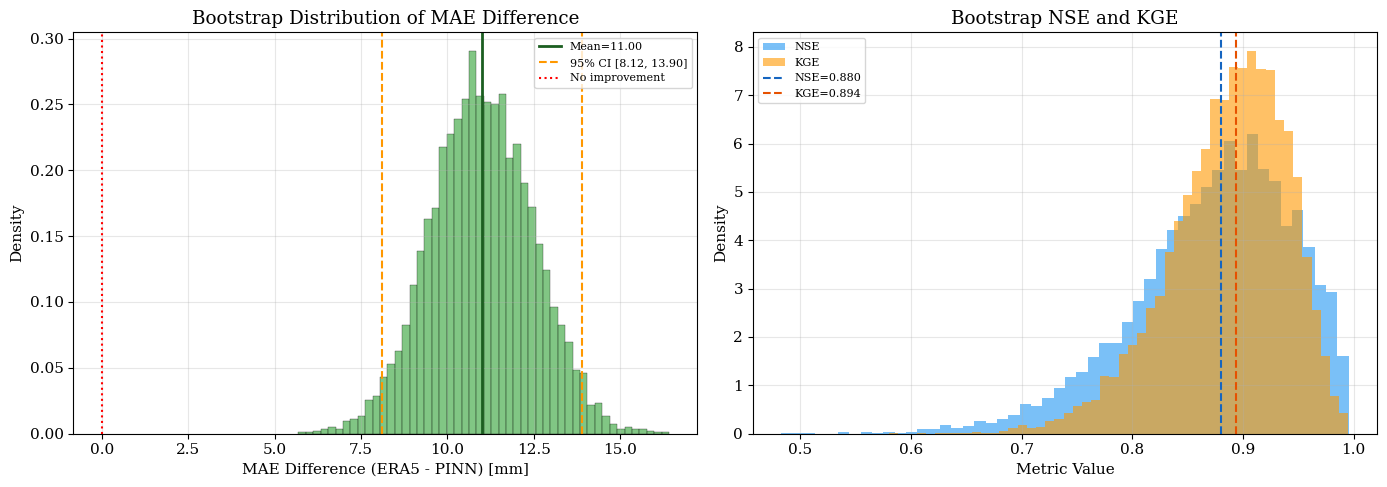


✅ PINN LOO validation complete.
Figures saved in: figures
Tables saved in: tables


In [3]:
# ============================================================
# PINN-LSTM for ERA5-Land SWE Bias Correction
# Leave-One-Out Validation with Multi-Seed Averaging
# Shemonaikha Region, Kazakhstan (50.62°N, 81.92°E)
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from scipy import stats
from sklearn.utils import resample
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings('ignore')

# Reproducibility: fixed set of seeds for averaging (no seed selection)
SEEDS = [42, 123, 456, 789, 1024]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Output directories
FIG_DIR = 'figures'
TABLE_DIR = 'tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Paths to data (relative to repository structure)
DATA_PATH = '../../data_preprocessing/processed/shemonaikha_snow_dataset_2014_2023.csv'
OBS_PATH  = '../../data_preprocessing/data/shemonaikha.csv'

# ============================================================================
# 1. Load and prepare data
# ============================================================================
print("\n📁 Loading data...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['era5_swe'] = df['swe_final']   # calibrated SWE

# Load station observations
obs = pd.read_csv(OBS_PATH)
obs['Date'] = obs['Date'].astype(str).str.replace('"', '').str.strip()
obs['Date'] = obs['Date'].str.replace(',$', '', regex=True)
obs['Date'] = pd.to_datetime(obs['Date'], format='%d.%m.%Y %H:%M')
obs['SWE'] = pd.to_numeric(obs['SWE'].astype(str).str.replace('"', '').str.replace(',', ''), errors='coerce')
obs['date'] = obs['Date'].dt.date
obs = obs.drop_duplicates(subset=['date']).copy()
obs['date'] = pd.to_datetime(obs['date'])
station_dict = dict(zip(obs['date'], obs['SWE']))
df['observed_swe'] = df['date'].map(station_dict)

# Snow season only (Oct–May)
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['water_year'] = df['year'] + (df['month'] >= 10).astype(int)
df_snow = df[(df['month'] >= 10) | (df['month'] <= 5)].copy().reset_index(drop=True)

print(f"Snow season days: {len(df_snow)}")
print(f"Observations: {df_snow['observed_swe'].notna().sum()}")

# ============================================================================
# 2. Feature engineering
# ============================================================================
def create_features(df_subset):
    n = len(df_subset)
    def get_vals(col):
        vals = df_subset[col]
        return vals.iloc[:, 0].values if isinstance(vals, pd.DataFrame) else vals.values

    temp = get_vals('temperature_2m_C')
    precip = get_vals('precipitation_mm')
    snow_cover = get_vals('snow_cover_ERA5')
    albedo = get_vals('forecast_albedo')
    snowmelt = get_vals('snowmelt_sum')
    solar_down = get_vals('surface_solar_radiation_downwards_sum')
    thermal_down = get_vals('surface_thermal_radiation_downwards_sum')
    u_wind = get_vals('u_component_of_wind_10m')
    v_wind = get_vals('v_component_of_wind_10m')
    soil_water = get_vals('volumetric_soil_water_layer_1')
    water_year = get_vals('water_year')
    doy = get_vals('doy')

    features = {}
    features['temperature_2m_C'] = temp
    features['precipitation_mm'] = precip
    features['snow_cover_ERA5'] = snow_cover
    features['forecast_albedo'] = albedo
    features['snowmelt_sum'] = snowmelt
    features['surface_solar_radiation_downwards_sum'] = solar_down
    features['surface_thermal_radiation_downwards_sum'] = thermal_down
    features['u_component_of_wind_10m'] = u_wind
    features['v_component_of_wind_10m'] = v_wind
    features['volumetric_soil_water_layer_1'] = soil_water

    features['wind_speed'] = np.sqrt(u_wind**2 + v_wind**2)
    albedo_clipped = np.clip(albedo, 0.3, 0.95)
    features['solar_net'] = solar_down * (1 - albedo_clipped)
    features['thermal_net'] = (thermal_down - 5.67e-8 * 273.15**4) / 1e6
    features['temp_melt_potential'] = np.maximum(temp - 0.5, 0)
    features['soil_moisture_pct'] = soil_water * 100
    features['doy_sin'] = np.sin(2 * np.pi * doy / 365)
    features['doy_cos'] = np.cos(2 * np.pi * doy / 365)

    unique_wy = np.unique(water_year)
    for lag in [1, 2, 3]:
        temp_lag = np.full(n, np.nan)
        precip_lag = np.full(n, np.nan)
        for wy in unique_wy:
            mask = water_year == wy
            idx = np.where(mask)[0]
            if len(idx) > lag:
                temp_lag[idx[lag:]] = temp[idx[:-lag]]
                precip_lag[idx[lag:]] = precip[idx[:-lag]]
        features[f'temp_lag{lag}'] = temp_lag
        features[f'precip_lag{lag}'] = precip_lag

    cumul_precip = np.full(n, np.nan)
    cumul_snowmelt = np.full(n, np.nan)
    for wy in unique_wy:
        mask = water_year == wy
        cumul_precip[mask] = np.cumsum(precip[mask])
        cumul_snowmelt[mask] = np.cumsum(snowmelt[mask])
    features['cumul_precip'] = cumul_precip
    features['cumul_snowmelt'] = cumul_snowmelt

    df_feat = pd.DataFrame(features, index=df_subset.index)
    df_feat = df_feat.ffill().fillna(0)
    return df_feat

# ============================================================================
# 3. PINN architecture (physics-informed)
# ============================================================================
class StablePINN(nn.Module):
    def __init__(self, feature_names):
        super().__init__()
        self.feature_names = feature_names

        # Learnable physical parameters
        self.raw_temp_melt = nn.Parameter(torch.tensor(0.5))
        self.raw_solar_melt = nn.Parameter(torch.tensor(-2.0))
        self.raw_thermal_melt = nn.Parameter(torch.tensor(-2.5))
        self.raw_wind_subl = nn.Parameter(torch.tensor(-3.0))
        self.raw_snow_threshold = nn.Parameter(torch.tensor(0.3))

        # Blending weights
        self.physics_weight = nn.Parameter(torch.tensor(0.5))
        self.era5_weight = nn.Parameter(torch.tensor(0.5))

        # Correction network
        self.corrector = nn.Sequential(
            nn.Linear(12, 24),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(24, 12),
            nn.ReLU(),
            nn.Linear(12, 1),
            nn.Tanh()
        )
        self.correction_scale = nn.Parameter(torch.tensor(1.0))

    @property
    def temp_melt_factor(self): return torch.nn.functional.softplus(self.raw_temp_melt) * 2.0
    @property
    def solar_melt_factor(self): return torch.nn.functional.softplus(self.raw_solar_melt) * 0.05
    @property
    def thermal_melt_factor(self): return torch.nn.functional.softplus(self.raw_thermal_melt) * 0.01
    @property
    def wind_sublimation_factor(self): return torch.nn.functional.softplus(self.raw_wind_subl) * 0.01
    @property
    def snow_threshold(self): return torch.nn.functional.softplus(self.raw_snow_threshold) + 0.5

    def _get_idx(self, name): return self.feature_names.index(name)

    def physics_forward(self, x):
        t = x[:, self._get_idx('temperature_2m_C')]
        p = x[:, self._get_idx('precipitation_mm')]
        sc = x[:, self._get_idx('snow_cover_ERA5')] / 100.0
        sn = x[:, self._get_idx('solar_net')]
        tn = x[:, self._get_idx('thermal_net')]
        w = x[:, self._get_idx('wind_speed')]
        sm = x[:, self._get_idx('soil_moisture_pct')]
        tp = x[:, self._get_idx('temp_melt_potential')]

        snow_frac = torch.sigmoid(-3 * (t - self.snow_threshold))
        snowfall = p * snow_frac * torch.clamp(sc, min=0.05)
        temp_melt = self.temp_melt_factor * tp * sc
        solar_melt = self.solar_melt_factor * torch.clamp(sn, min=0) * sc
        thermal_melt = self.thermal_melt_factor * torch.clamp(tn, min=0) * sc
        soil_melt = 0.001 * sm * sc * tp
        sub_cond = torch.sigmoid(2 * (t + 5))
        sublimation = self.wind_sublimation_factor * w * sc * sub_cond
        total_melt = temp_melt + solar_melt + thermal_melt + soil_melt
        dswe_dt = snowfall - total_melt - sublimation
        return dswe_dt, snowfall, total_melt, sublimation

    def forward(self, x, swe_prev, era5_current, era5_prev):
        if x.dim() == 1: x = x.unsqueeze(0)
        dswe_dt, snowfall, total_melt, sublimation = self.physics_forward(x)
        swe_physics = swe_prev + dswe_dt.unsqueeze(1)
        swe_physics = torch.clamp(swe_physics, min=0)

        w_phys = torch.sigmoid(self.physics_weight)
        w_era5 = torch.sigmoid(self.era5_weight)
        swe_blend = (w_phys * swe_physics + w_era5 * era5_current) / (w_phys + w_era5 + 1e-8)

        corr_features = torch.cat([
            dswe_dt.unsqueeze(1), snowfall.unsqueeze(1),
            total_melt.unsqueeze(1), sublimation.unsqueeze(1),
            (swe_physics - era5_current), (swe_prev - era5_prev),
            x[:, self._get_idx('temperature_2m_C')].unsqueeze(1),
            x[:, self._get_idx('snow_cover_ERA5')].unsqueeze(1) / 100.0,
            x[:, self._get_idx('cumul_precip')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('cumul_snowmelt')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('doy_sin')].unsqueeze(1),
            x[:, self._get_idx('doy_cos')].unsqueeze(1)
        ], dim=1)

        scale = torch.nn.functional.softplus(self.correction_scale) * 10.0
        correction = self.corrector(corr_features) * scale
        swe_corrected = swe_blend + correction
        swe_corrected = torch.clamp(swe_corrected, min=0)
        return swe_corrected, swe_physics, correction

    def run_sequence(self, X, era5_swe, warmup_steps=10):
        seq_len = X.shape[0]
        swe_pred = torch.zeros(seq_len, 1, device=X.device)
        swe_physics_out = torch.zeros(seq_len, 1, device=X.device)
        corr_out = torch.zeros(seq_len, 1, device=X.device)

        swe_pred[0] = era5_swe[0]
        swe_physics_out[0] = era5_swe[0]

        for t in range(1, seq_len):
            swe_pred[t], swe_physics_out[t], corr_out[t] = self(
                X[t:t+1], swe_pred[t-1:t],
                era5_swe[t:t+1], era5_swe[t-1:t]
            )
        warmup_mask = torch.zeros(seq_len, 1, dtype=torch.bool, device=X.device)
        warmup_mask[:warmup_steps] = True
        return swe_pred, swe_physics_out, corr_out, warmup_mask

def stable_loss(swe_pred, era5, obs, correction, active_mask):
    obs_mask = ~torch.isnan(obs) & active_mask
    if obs_mask.sum() > 0:
        diff = torch.abs(swe_pred[obs_mask] - obs[obs_mask])
        loss_obs = torch.where(diff < 10.0, 0.5 * diff**2, 10.0 * diff - 50.0).mean()
    else:
        loss_obs = torch.tensor(0.0, device=swe_pred.device)

    loss_era5 = torch.mean((swe_pred[active_mask] - era5[active_mask])**2) * 0.01
    loss_corr = torch.mean(correction[active_mask]**2) * 0.1

    swe_active = swe_pred[active_mask]
    loss_smooth = torch.mean(torch.abs(swe_active[1:] - swe_active[:-1])) * 0.001 if swe_active.shape[0] > 1 else torch.tensor(0.0, device=swe_pred.device)
    return loss_obs + loss_era5 + loss_corr + loss_smooth, loss_obs

# ============================================================================
# 4. LOO with multi-seed averaging
# ============================================================================
print("\n🔁 Running LOO with 5 fixed seeds...")
obs_dates = df_snow[df_snow['observed_swe'].notna()]['date'].values
obs_indices = [df_snow[df_snow['date'] == d].index[0] for d in obs_dates]

y_true = df_snow.loc[obs_indices, 'observed_swe'].values.astype(float)
era5_true = df_snow.loc[obs_indices, 'era5_swe'].values.astype(float)

# Store predictions per seed
predictions_by_seed = {seed: [] for seed in SEEDS}

for seed in SEEDS:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    for test_idx in obs_indices:
        start_idx = max(0, test_idx - 89)
        df_subset = df_snow.iloc[start_idx:test_idx+1].copy()
        df_features = create_features(df_subset)
        feature_names = df_features.columns.tolist()

        scaler = RobustScaler()
        scaled_feat = scaler.fit_transform(df_features.values)
        X = torch.FloatTensor(scaled_feat).to(DEVICE)
        era5 = torch.FloatTensor(df_subset['era5_swe'].values.reshape(-1, 1)).to(DEVICE)
        obs = torch.FloatTensor(df_subset['observed_swe'].values.reshape(-1, 1)).to(DEVICE)

        model = StablePINN(feature_names).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

        for epoch in range(50):
            optimizer.zero_grad()
            swe_pred, _, corr, warmup = model.run_sequence(X, era5, warmup_steps=10)
            active = ~warmup
            loss, _ = stable_loss(swe_pred, era5, obs, corr, active)
            if not torch.isnan(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        model.eval()
        with torch.no_grad():
            swe_pred, _, _, _ = model.run_sequence(X, era5, warmup_steps=0)
            predictions_by_seed[seed].append(max(0, swe_pred[-1].item()))

    print(f"Seed {seed} completed")

# Average predictions across seeds
pinn_pred = np.mean([np.array(predictions_by_seed[s]) for s in SEEDS], axis=0)

# ============================================================================
# 5. Full metrics calculation
# ============================================================================
def nse(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / (np.sum((y_true - np.mean(y_true))**2) + 1e-10)

def kge(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[0,1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)

def willmott_d(y_true, y_pred):
    return 1 - np.sum((y_pred - y_true)**2) / np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true)))**2 + 1e-10)

def pbias(y_true, y_pred):
    return 100 * np.sum(y_pred - y_true) / (np.sum(y_true) + 1e-10)

def rsr(y_true, y_pred):
    return np.sqrt(np.sum((y_true - y_pred)**2)) / (np.sqrt(np.sum((y_true - np.mean(y_true))**2)) + 1e-10)

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)) * 100

def explained_variance(y_true, y_pred):
    return 1 - np.var(y_true - y_pred) / (np.var(y_true) + 1e-10)

def full_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    nse_val = nse(y_true, y_pred)
    kge_val = kge(y_true, y_pred)
    d = willmott_d(y_true, y_pred)
    pb = pbias(y_true, y_pred)
    rs = rsr(y_true, y_pred)
    mp = mape(y_true, y_pred)
    sm = smape(y_true, y_pred)
    ev = explained_variance(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'NSE': nse_val, 'KGE': kge_val,
            "Willmott's d": d, 'PBIAS (%)': pb, 'RSR': rs, 'MAPE (%)': mp,
            'SMAPE (%)': sm, 'Explained Var': ev, 'Pearson r': corr}

era5_metrics = full_metrics(y_true, era5_true)
pinn_metrics = full_metrics(y_true, pinn_pred)

# ============================================================================
# 6. Statistical tests
# ============================================================================
errors_era5 = np.abs(y_true - era5_true)
errors_pinn = np.abs(y_true - pinn_pred)

wilcoxon_stat, wilcoxon_p = stats.wilcoxon(errors_era5, errors_pinn)
t_stat, t_p = stats.ttest_rel(errors_era5, errors_pinn)
u_stat, u_p = stats.mannwhitneyu(errors_era5, errors_pinn, alternative='two-sided')
ks_stat, ks_p = stats.ks_2samp(errors_era5, errors_pinn)

# Bootstrap CIs
n_boot = 10000
rng = np.random.RandomState(7772)
mae_diffs_boot = np.zeros(n_boot)
nse_boot = np.zeros(n_boot)
kge_boot = np.zeros(n_boot)
n = len(y_true)

for i in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    mae_diffs_boot[i] = mean_absolute_error(y_true[idx], era5_true[idx]) - mean_absolute_error(y_true[idx], pinn_pred[idx])
    nse_boot[i] = nse(y_true[idx], pinn_pred[idx])
    kge_boot[i] = kge(y_true[idx], pinn_pred[idx])

mae_diff_mean = np.mean(mae_diffs_boot)
mae_diff_ci = np.percentile(mae_diffs_boot, [2.5, 97.5])
nse_ci = np.percentile(nse_boot, [2.5, 97.5])
kge_ci = np.percentile(kge_boot, [2.5, 97.5])

improved_mask = errors_pinn < errors_era5
improved_pct = improved_mask.sum() / n * 100

# ============================================================================
# 7. Print tables
# ============================================================================
print("\n" + "="*80)
print("TABLE 1: COMPLETE METRICS COMPARISON")
print("="*80)
print(f"{'Metric':<20} {'ERA5':>10} {'PINN (avg)':>12} {'Improvement':>15}")
print("-"*60)
for metric in pinn_metrics.keys():
    e = era5_metrics[metric]
    p = pinn_metrics[metric]
    if metric in ['MAE','RMSE','RSR','MAPE (%)','SMAPE (%)']:
        delta = e - p
        impr = f"↓{delta:.2f}"
    elif metric == 'PBIAS (%)':
        delta = abs(e) - abs(p)
        impr = f"↓{delta:.1f}%"
    else:
        delta = p - e
        impr = f"↑{delta:.3f}"
    print(f"{metric:<20} {e:>10.3f} {p:>12.3f} {impr:>15}")

print("\n" + "="*80)
print("TABLE 2: STATISTICAL TESTS")
print("="*80)
print(f"Wilcoxon signed-rank: stat={wilcoxon_stat:.2f}, p={wilcoxon_p:.6f}")
print(f"Paired t-test:        t={t_stat:.4f}, p={t_p:.6f}")
print(f"Mann-Whitney U:       U={u_stat:.2f}, p={u_p:.6f}")
print(f"Kolmogorov-Smirnov:   KS={ks_stat:.4f}, p={ks_p:.6f}")

print("\n" + "="*80)
print("TABLE 3: BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("="*80)
print(f"MAE difference (ERA5 - PINN): {mae_diff_mean:.2f} mm, CI [{mae_diff_ci[0]:.2f}, {mae_diff_ci[1]:.2f}]")
print(f"PINN NSE: {pinn_metrics['NSE']:.3f}, CI [{nse_ci[0]:.3f}, {nse_ci[1]:.3f}]")
print(f"PINN KGE: {pinn_metrics['KGE']:.3f}, CI [{kge_ci[0]:.3f}, {kge_ci[1]:.3f}]")
print(f"Improved points: {improved_mask.sum()}/{n} ({improved_pct:.1f}%)")

# Save metrics table
metrics_df = pd.DataFrame({'ERA5': era5_metrics, 'PINN_avg': pinn_metrics}).T.round(3)
metrics_df.to_csv(os.path.join(TABLE_DIR, 'PINN_LOO_metrics_avg5seeds.csv'))

# ============================================================================
# 8. Publication-quality figures
# ============================================================================
plt.rcParams.update({'font.size': 11, 'font.family': 'serif', 'mathtext.fontset': 'stix'})

# Figure A: Scatter plot + error distribution + boxplot + corrections + CDF + metrics bar
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PINN-LSTM Performance (Averaged over 5 Seeds) – LOO Validation', fontsize=15, fontweight='bold')

# A1: Scatter plot
ax = axes[0,0]
max_val = max(y_true.max(), era5_true.max(), pinn_pred.max()) * 1.1
ax.scatter(y_true, era5_true, alpha=0.6, s=50, color='#2196F3', label=f'ERA5 (MAE={era5_metrics["MAE"]:.1f})', edgecolors='white')
ax.scatter(y_true, pinn_pred, alpha=0.8, s=60, color='#4CAF50', label=f'PINN (MAE={pinn_metrics["MAE"]:.2f})', edgecolors='white')
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3)
ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
ax.set_xlabel('Observed SWE (mm)'); ax.set_ylabel('Modeled SWE (mm)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_title('(a) Scatter Plot')

# A2: Error distribution
ax = axes[0,1]
bins = np.linspace(-60, 60, 30)
ax.hist(y_true - era5_true, bins=bins, alpha=0.6, color='#2196F3', density=True, label=f'ERA5 (σ={np.std(y_true-era5_true):.1f})')
ax.hist(y_true - pinn_pred, bins=bins, alpha=0.7, color='#4CAF50', density=True, label=f'PINN (σ={np.std(y_true-pinn_pred):.1f})')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.axvline(np.mean(y_true-era5_true), color='#1565C0', linewidth=2, label=f'ERA5 bias={np.mean(y_true-era5_true):.1f}')
ax.axvline(np.mean(y_true-pinn_pred), color='#1B5E20', linewidth=2, label=f'PINN bias={np.mean(y_true-pinn_pred):.1f}')
ax.set_xlabel('Error (mm)'); ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('(b) Error Distribution')

# A3: Boxplot of errors
ax = axes[0,2]
bp = ax.boxplot([y_true - era5_true, y_true - pinn_pred], labels=['ERA5','PINN'], patch_artist=True, showfliers=False)
colors = ['#2196F3','#4CAF50']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.axhline(0, color='red', linestyle='--')
ax.set_ylabel('Error (mm)')
ax.grid(alpha=0.3)
ax.set_title('(c) Error Boxplot')

# A4: Point-by-point improvement
ax = axes[1,0]
improvement_per_point = errors_era5 - errors_pinn
colors_points = ['#4CAF50' if imp > 0 else '#F44336' for imp in improvement_per_point]
ax.bar(range(n), improvement_per_point, color=colors_points, alpha=0.7)
ax.axhline(0, color='k', linewidth=1)
ax.axhline(np.mean(improvement_per_point), color='#FF9800', linestyle='--', label=f'Mean={np.mean(improvement_per_point):.1f}')
ax.set_xlabel('Observation Point'); ax.set_ylabel('Error Reduction (ERA5 - PINN) [mm]')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title(f'(d) Point-by-Point Improvement ({improved_mask.sum()}/{n} improved)')

# A5: CDF of absolute errors
ax = axes[1,1]
sorted_era5 = np.sort(errors_era5)
sorted_pinn = np.sort(errors_pinn)
cdf_y = np.arange(1, n+1) / n
ax.plot(sorted_era5, cdf_y, '-', color='#2196F3', label='ERA5')
ax.plot(sorted_pinn, cdf_y, '-', color='#4CAF50', label='PINN')
ax.axvline(np.median(errors_era5), color='#1565C0', linestyle='--', label=f'ERA5 median={np.median(errors_era5):.1f}')
ax.axvline(np.median(errors_pinn), color='#1B5E20', linestyle='--', label=f'PINN median={np.median(errors_pinn):.1f}')
ax.set_xlabel('Absolute Error (mm)'); ax.set_ylabel('CDF')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('(e) CDF of Absolute Errors')

# A6: Metrics bar chart
ax = axes[1,2]
metrics_names = ['NSE', 'KGE', "Willmott's d", 'R2']
era5_vals = [era5_metrics[m] for m in metrics_names]
pinn_vals = [pinn_metrics[m] for m in metrics_names]
x_pos = np.arange(len(metrics_names))
width = 0.35
bars1 = ax.bar(x_pos - width/2, era5_vals, width, color='#2196F3', label='ERA5')
bars2 = ax.bar(x_pos + width/2, pinn_vals, width, color='#4CAF50', label='PINN')
for bar, val in zip(bars1, era5_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, pinn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_title('(f) Performance Metrics')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_dashboard_metrics.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_dashboard_metrics.pdf'), bbox_inches='tight')
plt.show()

# Figure B: Bootstrap distribution of MAE difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(mae_diffs_boot, bins=50, color='#4CAF50', alpha=0.7, density=True, edgecolor='k', linewidth=0.3)
ax.axvline(mae_diff_mean, color='#1B5E20', linewidth=2, label=f'Mean={mae_diff_mean:.2f}')
ax.axvline(mae_diff_ci[0], color='#FF9800', linestyle='--', label=f'95% CI [{mae_diff_ci[0]:.2f}, {mae_diff_ci[1]:.2f}]')
ax.axvline(mae_diff_ci[1], color='#FF9800', linestyle='--')
ax.axvline(0, color='red', linestyle=':', label='No improvement')
ax.set_xlabel('MAE Difference (ERA5 - PINN) [mm]')
ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Bootstrap Distribution of MAE Difference')

ax = axes[1]
ax.hist(nse_boot, bins=50, color='#2196F3', alpha=0.6, density=True, label='NSE')
ax.hist(kge_boot, bins=50, color='#FF9800', alpha=0.6, density=True, label='KGE')
ax.axvline(pinn_metrics['NSE'], color='#1565C0', linestyle='--', label=f'NSE={pinn_metrics["NSE"]:.3f}')
ax.axvline(pinn_metrics['KGE'], color='#E65100', linestyle='--', label=f'KGE={pinn_metrics["KGE"]:.3f}')
ax.set_xlabel('Metric Value'); ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Bootstrap NSE and KGE')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_bootstrap_ci.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_bootstrap_ci.pdf'), bbox_inches='tight')
plt.show()

print("\n✅ PINN LOO validation complete.")
print("Figures saved in:", FIG_DIR)
print("Tables saved in:", TABLE_DIR)